In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

I0000 00:00:1787333703.488048   14551 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787333703.490435   14551 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787333703.741376   14551 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787333705.054460   14551 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [3]:
iris = load_iris()
X = iris.data
y = iris.target
print("Dataset shape:", X.shape)

Dataset shape: (150, 4)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
X,y,test_size=0.2,
random_state=42)

In [25]:
model = tf.keras.Sequential([
tf.keras.layers.Dense(
16,
activation="relu",
input_shape=(4,)
),
tf.keras.layers.Dense(
3,
activation="softmax"
)
])

In [26]:
model.compile(
optimizer="adam",
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]
)

In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [67]:
history = model.fit(
X_train,
y_train,
epochs=10,
validation_split=0.2
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9479 - loss: 0.4267 - val_accuracy: 1.0000 - val_loss: 0.4740
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9479 - loss: 0.4244 - val_accuracy: 1.0000 - val_loss: 0.4726
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9688 - loss: 0.4224 - val_accuracy: 1.0000 - val_loss: 0.4685
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9688 - loss: 0.4199 - val_accuracy: 1.0000 - val_loss: 0.4654
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9688 - loss: 0.4174 - val_accuracy: 1.0000 - val_loss: 0.4632
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9688 - loss: 0.4155 - val_accuracy: 1.0000 - val_loss: 0.4599
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9688 - loss: 0.4130 - val_accuracy: 1.0000 - val_loss: 0.4587
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9583 - loss: 0.4110 - val_accuracy: 1.0000 - val_loss: 0.4579


In [68]:
loss, accuracy = model.evaluate(
X_test,
y_test
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.4216


In [69]:
print("Test Accuracy:", accuracy)

Test Accuracy: 1.0


In [70]:
predictions = model.predict(X_test[:5])
predicted_classes = predictions.argmax(axis=1)
print("\nPredicted classes:", predicted_classes)
print("Actual classes   :", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Predicted classes: [1 0 2 1 1]
Actual classes   : [1 0 2 1 1]


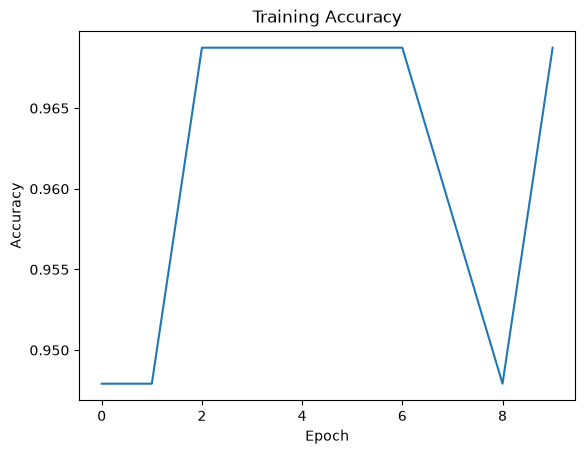

In [71]:
plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()